In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import contextily as cx
import os
import sys
import importlib

In [10]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src"))) #use this to be able to import local packages
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../EPM"))) #use this to be able to import local packages

In [13]:
import utils.utils
importlib.reload(utils.utils)
import utils.config
importlib.reload(utils.config)

from utils.utils import *
from utils.config import *

new config loaded from ../EPM/transient/EPM_calibration.yaml
error loading geojsons
error loading csvs


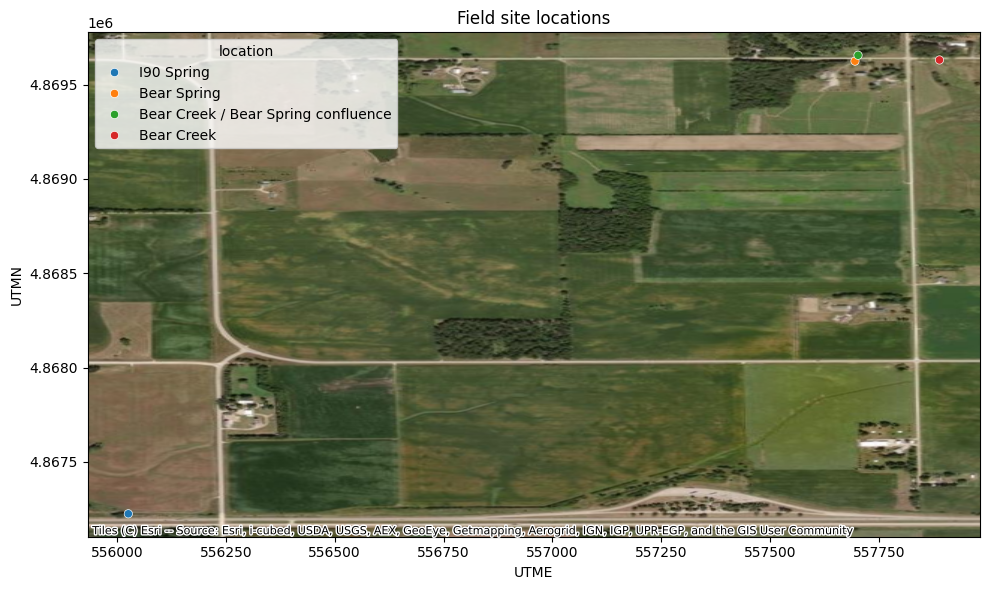

In [25]:
fig, ax = plt.subplots(figsize = (10,6))
config = Config('../EPM/transient/EPM_calibration.yaml')
field_sites = pd.read_csv("../data/geo_data/field_site_locations.csv")
field_sites = field_sites[~field_sites["location_id"].isin(["bs", "bs_overflow"])]
field_sites['location'] = field_sites['location_id'].map({'bs_data' : 'Bear Spring', 'bcbs' : 'Bear Creek / Bear Spring confluence', 'bc' : 'Bear Creek', '55A405' : 'I90 Spring'})
# plt.colorbar(label = "Conduit frequency")
source = cx.providers.Esri.WorldImagery
sns.scatterplot(field_sites, x = "UTME", y = 'UTMN', hue = 'location')

# sns.scatterplot(ax = ax, data = nodes[nodes.type == 'outfall'], x= 'x', y ='y', color = 'blue', label = 'spring')
cx.add_basemap(
    ax, 
    crs=config.crs, 
    source=source, 
    zoom="auto"
)
plt.title("Field site locations")
plt.tight_layout()
